In [ ]:
from __future__ import annotations

import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision.models import Inception_V3_Weights, inception_v3

In [ ]:
NUM_CLASSES, LATENT_DIM, EMBED_DIM = 10, 96, 48
G_CHANNELS, D_CHANNELS = 128, 64
BATCH_SIZE, EPOCHS = 128, 60
LR_G, LR_D = 2e-4, 1e-4 
EMA_DECAY, SEED = 0.999, 2026
NUM_WORKERS = 0 
RUN_FID = False
FID_SAMPLES_PER_CLASS = 5000

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def init_weights(module: nn.Module) -> None:
    """DCGAN initialization without breaking spectral normalization."""
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        weight = getattr(module, "weight_orig", module.weight)
        nn.init.normal_(weight, 0.0, 0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
        nn.init.normal_(module.weight, 1.0, 0.02)
        nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, 0.0, 0.02)

In [ ]:
class Generator(nn.Module):

    def __init__(self) -> None:
        super().__init__()
        self.embedding = nn.Embedding(NUM_CLASSES, EMBED_DIM)
        self.project = nn.Sequential(
            nn.Linear(LATENT_DIM + EMBED_DIM, G_CHANNELS * 7 * 7),
            nn.BatchNorm1d(G_CHANNELS * 7 * 7),
            nn.ReLU(inplace=True),
        )
        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),  # 7 -> 14
            nn.Conv2d(G_CHANNELS, G_CHANNELS // 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(G_CHANNELS // 2),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode="nearest"),  # 14 -> 28
            nn.Conv2d(G_CHANNELS // 2, G_CHANNELS // 4, 3, 1, 1, bias=False),
            nn.BatchNorm2d(G_CHANNELS // 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(G_CHANNELS // 4, 1, 3, 1, 1),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        x = torch.cat((z, self.embedding(labels)), dim=1)
        return self.net(self.project(x).view(-1, G_CHANNELS, 7, 7))


class ProjectionDiscriminator(nn.Module):
    """Spectral-normalized projection discriminator for hinge-GAN training."""

    def __init__(self) -> None:
        super().__init__()

        def sn_conv(inp: int, out: int, kernel: int, stride: int, pad: int) -> nn.Module:
            return nn.utils.spectral_norm(nn.Conv2d(inp, out, kernel, stride, pad))

        self.features = nn.Sequential(
            sn_conv(1, D_CHANNELS, 4, 2, 1),  # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            sn_conv(D_CHANNELS, D_CHANNELS * 2, 4, 2, 1),  # 14 -> 7
            nn.LeakyReLU(0.2, inplace=True),
            sn_conv(D_CHANNELS * 2, D_CHANNELS * 2, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),
        )
        feature_dim = D_CHANNELS * 2
        self.unconditional = nn.utils.spectral_norm(nn.Linear(feature_dim, 1))
        self.embedding = nn.Embedding(NUM_CLASSES, feature_dim)

    def forward(self, images: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        features = self.features(images).sum(dim=(2, 3))
        return self.unconditional(features) + (features * self.embedding(labels)).sum(dim=1, keepdim=True)

In [ ]:
@torch.no_grad()
def update_ema(ema_model: nn.Module, model: nn.Module, decay: float) -> None:
    for ema_parameter, parameter in zip(ema_model.parameters(), model.parameters()):
        ema_parameter.lerp_(parameter, 1.0 - decay)
    for ema_buffer, buffer in zip(ema_model.buffers(), model.buffers()):
        ema_buffer.copy_(buffer)


def set_requires_grad(model: nn.Module, value: bool) -> None:
    for parameter in model.parameters():
        parameter.requires_grad_(value)


def train(
    generator: Generator,
    discriminator: ProjectionDiscriminator,
    train_loader: DataLoader,
    device: torch.device,
    epochs: int,
) -> tuple[Generator, list[float], list[float]]:
    """One balanced D update and one G update per minibatch."""
    generator.train()
    discriminator.train()
    generator_ema = copy.deepcopy(generator).eval()
    set_requires_grad(generator_ema, False)
    optimizer_g = optim.Adam(generator.parameters(), lr=LR_G, betas=(0.0, 0.9))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.0, 0.9))
    d_history: list[float] = []
    g_history: list[float] = []

    for epoch in range(1, epochs + 1):
        d_total = g_total = 0.0
        image_count = 0
        for real_images, labels in train_loader:
            real_images = real_images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            current_batch_size = real_images.shape[0]

            # Hinge discriminator loss; uniformly sampled fake labels prevent a small class-frequency bias from each shuffled real minibatch.
            optimizer_d.zero_grad(set_to_none=True)
            fake_labels = torch.randint(NUM_CLASSES, (current_batch_size,), device=device)
            noise = torch.randn(current_batch_size, LATENT_DIM, device=device)
            with torch.no_grad():
                fake_images = generator(noise, fake_labels)
            d_real = discriminator(real_images, labels)
            d_fake = discriminator(fake_images, fake_labels)
            d_loss = F.relu(1.0 - d_real).mean() + F.relu(1.0 + d_fake).mean()
            d_loss.backward()
            optimizer_d.step()

            set_requires_grad(discriminator, False)
            optimizer_g.zero_grad(set_to_none=True)
            gen_labels = torch.randint(NUM_CLASSES, (current_batch_size,), device=device)
            noise = torch.randn(current_batch_size, LATENT_DIM, device=device)
            generated = generator(noise, gen_labels)
            g_loss = -discriminator(generated, gen_labels).mean()
            g_loss.backward()
            optimizer_g.step()
            set_requires_grad(discriminator, True)
            update_ema(generator_ema, generator, EMA_DECAY)

            d_total += d_loss.item() * current_batch_size
            g_total += g_loss.item() * current_batch_size
            image_count += current_batch_size

        d_history.append(d_total / image_count)
        g_history.append(g_total / image_count)
        print(f"Epoch [{epoch:>3}/{epochs}] - D loss: {d_history[-1]:.4f} - G loss: {g_history[-1]:.4f}")
    return generator_ema, d_history, g_history

In [ ]:
@torch.inference_mode()
def generate_by_class(generator: Generator, samples_per_class: int, device: torch.device) -> torch.Tensor:
    generator.eval()
    all_images = []
    for label in range(NUM_CLASSES):
        class_images = []
        for start in range(0, samples_per_class, BATCH_SIZE):
            batch = min(BATCH_SIZE, samples_per_class - start)
            labels = torch.full((batch,), label, dtype=torch.long, device=device)
            class_images.append(generator(torch.randn(batch, LATENT_DIM, device=device), labels).cpu())
        all_images.append(torch.cat(class_images))
    return torch.cat(all_images)


def save_grid(generator: Generator, device: torch.device, destination: Path) -> None:
    generator.eval()
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(10)
    with torch.inference_mode():
        images = generator(torch.randn(len(labels), LATENT_DIM, device=device), labels).cpu()
    grid = vutils.make_grid(images, nrow=10, normalize=True, value_range=(-1, 1), padding=2)
    vutils.save_image(grid, destination)


def show_samples(generator: Generator, device: torch.device) -> None:
    generator.eval()
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(10)
    with torch.inference_mode():
        images = generator(torch.randn(len(labels), LATENT_DIM, device=device), labels).cpu()
    grid = vutils.make_grid(images, nrow=10, normalize=True, value_range=(-1, 1), padding=2)
    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Each row is one requested digit label: 0 to 9")
    plt.show()


def plot_losses(d_losses: list[float], g_losses: list[float], destination: Path) -> None:
    plt.figure(figsize=(8, 4))
    plt.plot(d_losses, label="D (hinge)")
    plt.plot(g_losses, label="G (hinge)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(destination, dpi=150)
    plt.show()
    plt.close()

In [ ]:
def inception_features(images: torch.Tensor, extractor: nn.Module, device: torch.device, batch_size: int = 64) -> np.ndarray:
    """Extract official-preprocessed 2048-D Inception features from [-1, 1] MNIST."""
    features = []
    preprocess = Inception_V3_Weights.DEFAULT.transforms()
    extractor.eval()
    with torch.inference_mode():
        for start in range(0, len(images), batch_size):
            batch = images[start : start + batch_size].to(device)
            rgb = ((batch + 1.0) / 2.0).clamp(0, 1).repeat(1, 3, 1, 1)
            features.append(extractor(preprocess(rgb)).float().cpu().numpy())
    return np.concatenate(features)


def frechet_distance(real: np.ndarray, fake: np.ndarray) -> float:
    mean_real, mean_fake = real.mean(axis=0), fake.mean(axis=0)
    cov_real, cov_fake = np.cov(real, rowvar=False), np.cov(fake, rowvar=False)
    real_values, real_vectors = np.linalg.eigh(cov_real)
    sqrt_real = (real_vectors * np.sqrt(np.clip(real_values, 0.0, None))) @ real_vectors.T
    middle = sqrt_real @ cov_fake @ sqrt_real
    middle = (middle + middle.T) / 2.0 
    trace_sqrt = np.sqrt(np.clip(np.linalg.eigvalsh(middle), 0.0, None)).sum()
    return float((mean_real - mean_fake).dot(mean_real - mean_fake) + np.trace(cov_real) + np.trace(cov_fake) - 2.0 * trace_sqrt)


def conditional_fid(generator: Generator, dataset: datasets.MNIST, device: torch.device, samples_per_class: int) -> dict[int, float]:
    """Calculate full-covariance FID separately for every digit."""
    available = min(int((dataset.targets == label).sum()) for label in range(NUM_CLASSES))
    if not 2048 <= samples_per_class <= available:
        raise ValueError(f"fid samples/class must be in [2048, {available}]")
    fake_images = generate_by_class(generator, samples_per_class, device)
    extractor = inception_v3(weights=Inception_V3_Weights.DEFAULT).to(device)
    extractor.fc = nn.Identity()
    scores: dict[int, float] = {}
    for label in range(NUM_CLASSES):
        indices = torch.where(dataset.targets == label)[0][:samples_per_class]
        real_images = torch.stack([dataset[int(index)][0] for index in indices])
        fake_class = fake_images[label * samples_per_class : (label + 1) * samples_per_class]
        scores[label] = frechet_distance(
            inception_features(real_images, extractor, device),
            inception_features(fake_class, extractor, device),
        )
        print(f"Digit {label}: conditional FID = {scores[label]:.3f}")
    print(f"Mean conditional FID: {np.mean(list(scores.values())):.3f}")
    return scores

In [ ]:
set_seed(SEED)
device = choose_device()
print(f"Using device: {device}")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST("./data", train=True, transform=transform, download=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
generator, discriminator = Generator().to(device), ProjectionDiscriminator().to(device)
generator.apply(init_weights)
discriminator.apply(init_weights)

Using device: mps


ProjectionDiscriminator(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (unconditional): Linear(in_features=128, out_features=1, bias=True)
  (embedding): Embedding(10, 128)
)

Training for 60 epochs (batch size 128)...
Epoch [  1/60] - D loss: 1.4664 - G loss: 0.3565
Epoch [  2/60] - D loss: 1.5454 - G loss: 0.3638
Epoch [  3/60] - D loss: 1.7236 - G loss: 0.2453
Epoch [  4/60] - D loss: 1.8453 - G loss: 0.1467
Epoch [  5/60] - D loss: 1.8859 - G loss: 0.1165
Epoch [  6/60] - D loss: 1.8929 - G loss: 0.1215
Epoch [  7/60] - D loss: 1.8882 - G loss: 0.1043
Epoch [  8/60] - D loss: 1.8801 - G loss: 0.1022
Epoch [  9/60] - D loss: 1.8841 - G loss: 0.1340
Epoch [ 10/60] - D loss: 1.8799 - G loss: 0.1212
Epoch [ 11/60] - D loss: 1.8841 - G loss: 0.1157
Epoch [ 12/60] - D loss: 1.8850 - G loss: 0.1093
Epoch [ 13/60] - D loss: 1.8899 - G loss: 0.1114
Epoch [ 14/60] - D loss: 1.8982 - G loss: 0.1013
Epoch [ 15/60] - D loss: 1.9063 - G loss: 0.1124
Epoch [ 16/60] - D loss: 1.9086 - G loss: 0.1001
Epoch [ 17/60] - D loss: 1.9206 - G loss: 0.1058
Epoch [ 18/60] - D loss: 1.9216 - G loss: 0.0794
Epoch [ 19/60] - D loss: 1.9252 - G loss: 0.0736
Epoch [ 20/60] - D loss: 1

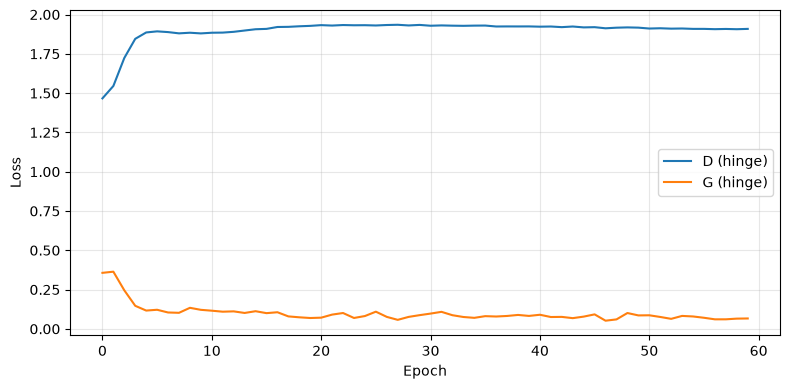

Saved checkpoints and plots to /Users/mukundareddy/personal/Git/AI/deep_learning/GANS/conditionalgan/artifacts


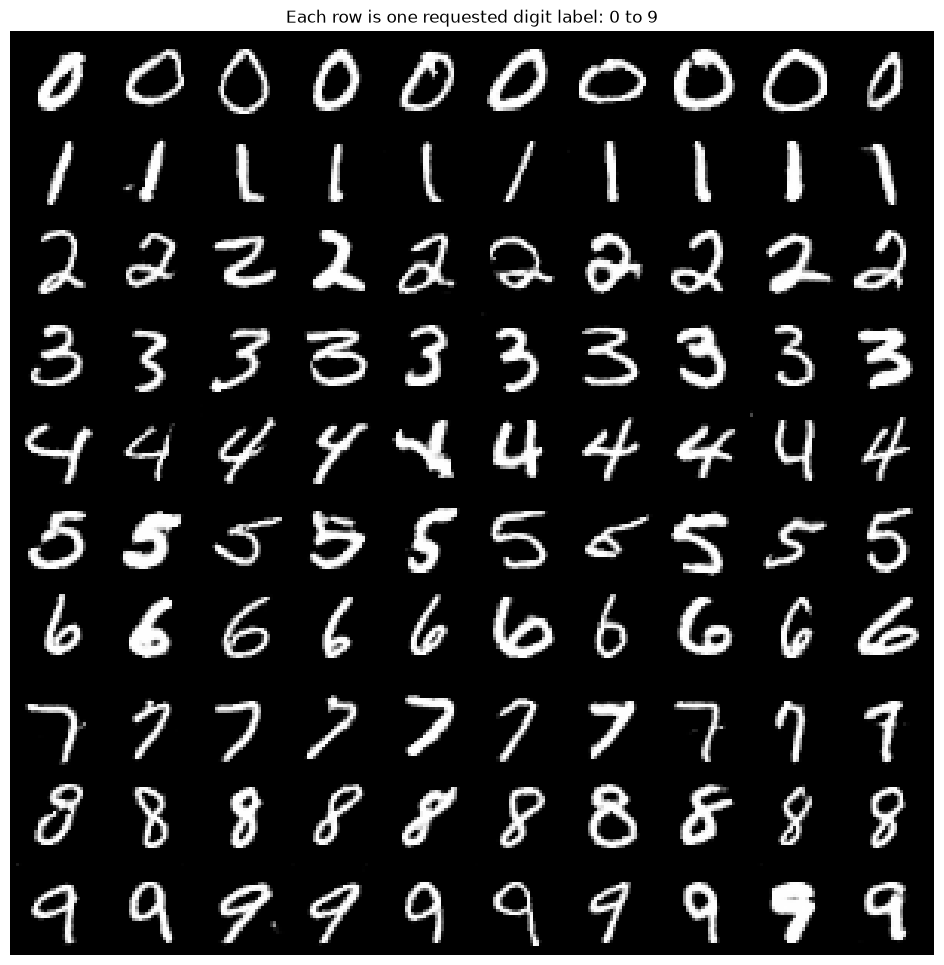

In [ ]:
print(f"Training for {EPOCHS} epochs (batch size {BATCH_SIZE})...")
generator_ema, d_losses, g_losses = train(generator, discriminator, train_loader, device, EPOCHS)

output_dir = Path("artifacts")
output_dir.mkdir(exist_ok=True)
torch.save({"generator": generator_ema.state_dict(), "seed": SEED}, output_dir / "generator_ema.pt")
torch.save({"discriminator": discriminator.state_dict(), "seed": SEED}, output_dir / "discriminator.pt")
save_grid(generator_ema, device, output_dir / "conditional_mnist_grid.png")
plot_losses(d_losses, g_losses, output_dir / "losses.png")
print(f"Saved checkpoints and plots to {output_dir.resolve()}")
show_samples(generator_ema, device)

In [ ]:
# This downloads Inception-v3 weights on first use and is deliberately not run
# unless RUN_FID is changed to True in the Configuration cell.
if RUN_FID:
    conditional_fid(generator_ema, train_dataset, device, FID_SAMPLES_PER_CLASS)

In [ ]:
conditional_fid(generator_ema, train_dataset, device, FID_SAMPLES_PER_CLASS)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /Users/mukundareddy/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100.0%


Digit 0: conditional FID = 6.919
Digit 1: conditional FID = 9.678
Digit 2: conditional FID = 6.705
Digit 3: conditional FID = 4.551
Digit 4: conditional FID = 5.017
Digit 5: conditional FID = 4.906
Digit 6: conditional FID = 6.605
Digit 7: conditional FID = 6.154
Digit 8: conditional FID = 4.388
Digit 9: conditional FID = 5.546
Mean conditional FID: 6.047


{0: 6.91858778685625,
 1: 9.677704330087266,
 2: 6.704975923503639,
 3: 4.5507437538816475,
 4: 5.017188935813863,
 5: 4.905951193424045,
 6: 6.604645746603865,
 7: 6.153746514787713,
 8: 4.388411518778781,
 9: 5.546250368194734}